# Binary Classification of Breast Tumors with PyTorch

## Scientific question

We have numerical measurements extracted from images of cell nuclei.

Can we use these measurements to predict whether a tumor sample is
**malignant** or **benign**?

### Target-label convention

The original scikit-learn dataset uses the following labels:

```text
target = 0 → malignant
target = 1 → benign
```

Immediately after loading the data, we replace `target` with a clearer column named `malignant`:

```text
malignant = 1.0 → malignant
malignant = 0.0 → benign
```

From that point onward, the notebook uses only `malignant`. This makes malignant the positive class used by precision, recall, and F1.

In this notebook, we will:

1. Load and inspect the dataset.
2. Check its quality and class distribution.
3. Separate features from the prediction target.
4. Split the data into training, validation, and test sets.
5. scale the numerical features without leaking information between datasets.
6. Prepare the data for use with PyTorch.

## 1. Setup

We begin by importing the libraries needed for data manipulation,
visualization, preprocessing, and dataset splitting.

PyTorch will be introduced after the data has been prepared.

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler


## 2. Load the dataset

We will use the Breast Cancer Wisconsin Diagnostic dataset included with
scikit-learn.

Each row represents one tumor sample.

The input features are numerical measurements derived from images of cell
nuclei. We immediately convert scikit-learn's `target` column into a
`malignant` column so the label convention stays clear in every later step.

In [67]:
dataset = load_breast_cancer(as_frame=True)
df = dataset.frame.copy()

# scikit-learn: target 0 = malignant, target 1 = benign
# our convention: malignant 1.0 = malignant, malignant 0.0 = benign
df["malignant"] = (df.pop("target") == 0).astype(np.float32)

In [68]:
print(f"Number of samples: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of samples: 569
Number of columns: 31


In [69]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,malignant
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1.0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1.0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1.0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1.0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1.0


### Understanding the feature names

The dataset contains measurements such as radius, texture, perimeter,
area, smoothness, and concavity.

For many properties, three versions are provided:

- `mean ...`: the average value across measured nuclei;
- `... error`: variation or standard error of the measurement;
- `worst ...`: the largest or most extreme observed value.

# 3. Inspecting the Data 

### Checking for missing values

In [70]:
print("Total missing values:", df.isna().sum().sum())

Total missing values: 0


### Checking for duplicates

In [71]:
number_of_duplicates = df.duplicated().sum()

print("Duplicated rows:", number_of_duplicates)

Duplicated rows: 0


### Checking the distribution of the `malignant` label:

- The classes are not perfectly balanced: there are more benign samples than
malignant samples.
- However, both classes contain a substantial number of observations.
- Later, we should evaluate the model with more than accuracy alone. In
particular, we will examine how many malignant samples are incorrectly
classified as benign.

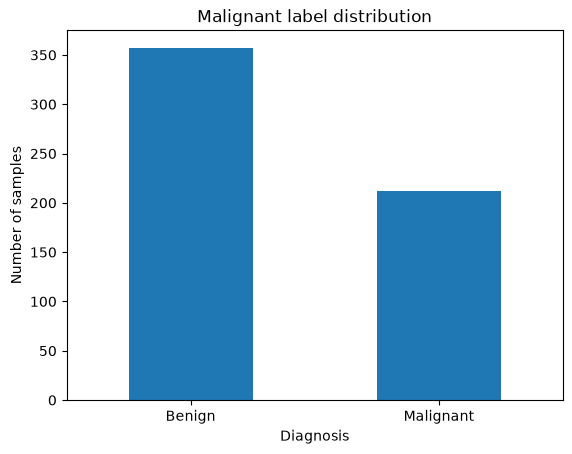

In [72]:
malignant_counts = (
    df["malignant"]
    .value_counts()
    .sort_index()
    .rename(index={0.0: "Benign", 1.0: "Malignant"})
)

malignant_counts.plot(kind="bar")

plt.title("Malignant label distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Number of samples")
plt.xticks(rotation=0)
plt.show()

### Checking for outliers
- We identified observations that fall outside the typical range, but we will not remove them. In biomedical datasets, extreme values may correspond to real patients rather than measurement errors. Removing them without domain knowledge could discard important biological information.

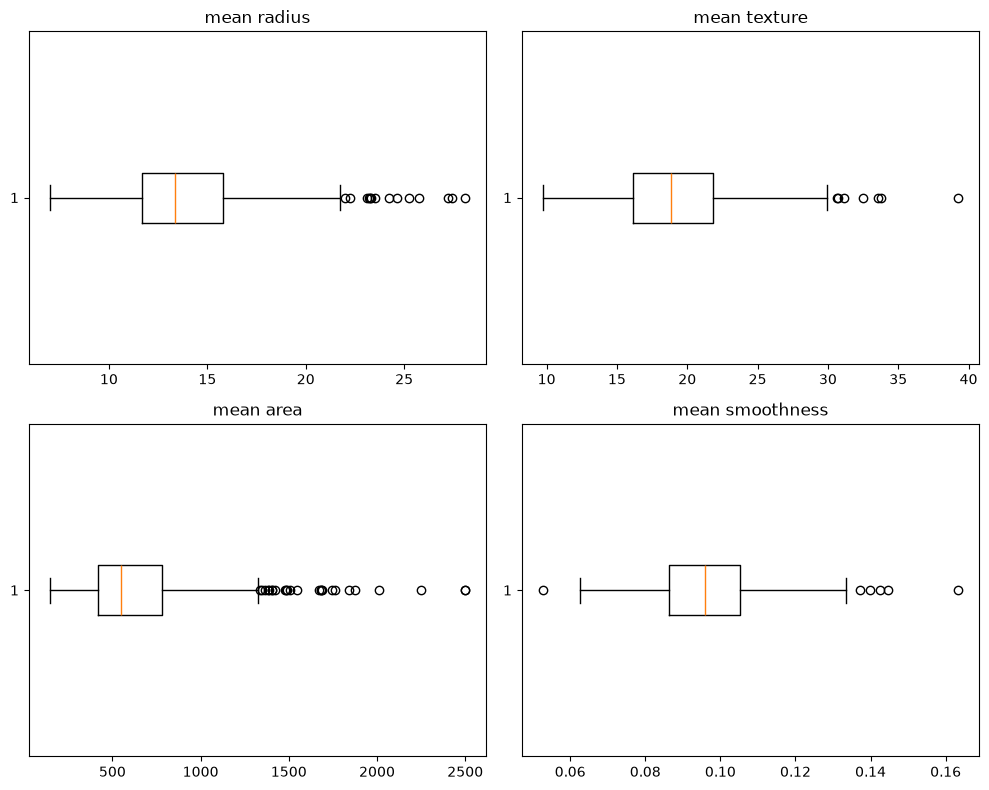

In [73]:
selected_features = [
    "mean radius",
    "mean texture",
    "mean area",
    "mean smoothness",
]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, feature in zip(axes.flatten(), selected_features):
    ax.boxplot(df[feature], orientation="horizontal")
    ax.set_title(feature)

plt.tight_layout()
plt.show()

# 4. Data Splits, Scaling and Saving

In [74]:
X = df.drop(columns="malignant")
y = df["malignant"]

### Splitting Data into Train, Val and Test (60%, 20%, 20%)

- **Train set** - Used to teach the model by finding patterns and adjusting internal weights.
- **Validation set** - Used during development to tune hyperparameters and choose the best model version.
- **Test set** - Kept completely hidden until the very end for a single, unbiased final exam score


In [75]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

In [76]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    random_state=42,
    stratify=y_train_val,
)

In [77]:
print(f"Training samples:   {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples:       {len(X_test)}")

Training samples:   341
Validation samples: 114
Test samples:       114


We want the distribution of the `malignant` label to be similar across the training, validation, and test sets. Let's check the class proportions in each set:

In [78]:
def class_distribution(target):
    return (
        target.value_counts(normalize=True)
        .sort_index()
        .rename(index={0.0: "Benign", 1.0: "Malignant"})
    )


distribution_table = pd.DataFrame({
    "Complete": class_distribution(y),
    "Training": class_distribution(y_train),
    "Validation": class_distribution(y_val),
    "Test": class_distribution(y_test),
})

distribution_table

,Complete,Training,Validation,Test
malignant,,,,
Benign,0.627417,0.627566,0.622807,0.631579
Malignant,0.372583,0.372434,0.377193,0.368421


### Scaling

- We need to scale the data because neural networks perorm better when the input values are on the same scale
- RobustScaler uses the median and interquartile range. It is less sensitive to extreme values than StandardScaler.
- The scaler must be fitted only on the training data to avoid data leakage

In [79]:
scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [80]:
X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X.columns,
    index=X_train.index,
)

X_val_scaled_df = pd.DataFrame(
    X_val_scaled,
    columns=X.columns,
    index=X_val.index,
)

X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=X.columns,
    index=X_test.index,
)

### Saving Data

In [81]:
train_df = X_train_scaled_df.copy()
train_df["malignant"] = y_train

val_df = X_val_scaled_df.copy()
val_df["malignant"] = y_val

test_df = X_test_scaled_df.copy()
test_df["malignant"] = y_test

In [82]:
processed_dir = "../data/processed/"
raw_dir = "../data/raw/"

In [83]:
train_df.to_csv(processed_dir + "train.csv", index=False)
val_df.to_csv(processed_dir + "validation.csv", index=False)
test_df.to_csv(processed_dir + "test.csv", index=False)

df.to_csv(raw_dir + "breast_cancer_data.csv", index=False)